In [6]:
import pandas as pd

# Load the CSV file (after downloading from Kaggle)
df = pd.read_csv(r"C:\Users\sowja\Downloads\marketing_AB.csv\marketing_AB.csv")

df.head()

,Unnamed: 0,user id,test group,converted,total ads,most ads day,most ads hour
0,0,1069124,ad,False,130,Monday,20
1,1,1119715,ad,False,93,Tuesday,22
2,2,1144181,ad,False,21,Tuesday,18
3,3,1435133,ad,False,355,Tuesday,10
4,4,1015700,ad,False,276,Friday,14


In [9]:
# Convert 'converted' from boolean to integer
df['converted'] = df['converted'].astype(int)

df[['test group', 'converted']].head()

,test group,converted
0,ad,0
1,ad,0
2,ad,0
3,ad,0
4,ad,0


In [11]:
# Split into control (PSA) and treatment (Ads)
control_df = df[df['test group'] == 'psa']
treatment_df = df[df['test group'] == 'ad']

# Count visitors
control_visitors = len(control_df)
treatment_visitors = len(treatment_df)

# Count conversions (users who bought)
control_conversions = control_df['converted'].sum()
treatment_conversions = treatment_df['converted'].sum()

print("Control:", control_visitors, control_conversions)
print("Treatment:", treatment_visitors, treatment_conversions)

Control: 23524 420
Treatment: 564577 14423


In [12]:
results = analyze_ab_test_results(
    control_visitors=control_visitors,
    control_conversions=control_conversions,
    treatment_visitors=treatment_visitors,
    treatment_conversions=treatment_conversions
)

print(results)

{'control_rate': 0.01785410644448223, 'treatment_rate': 0.025546559636683747, 'absolute_diff': 0.007692453192201517, 'relative_diff': 43.085064022225836, 'z_score': 8.657336478930567, 'p_value': 0.0, 'ci_lower': 0.0059509324316110055, 'ci_upper': 0.00943397395279203, 'is_significant': True}


📉 Typical Findings in This Dataset

In this dataset:

Ads were shown to ~96% of users

PSA group had only ~4% of users

Conversion rate for ads ~2.55% vs PSA ~1.79%

Z-score was extremely high and p-value extremely low → strong significance in most analyses

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Optional: make charts prettier
sns.set(style="whitegrid")

In [15]:
# Calculate conversion rates for each group
conversion_summary = df.groupby('test group')['converted'].agg(['mean', 'count', 'sum']).reset_index()
conversion_summary.rename(columns={'mean':'conversion_rate', 'count':'visitors', 'sum':'conversions'}, inplace=True)
print(conversion_summary)

  test group  conversion_rate  visitors  conversions
0         ad         0.025547    564577        14423
1        psa         0.017854     23524          420


C:\Users\sowja\AppData\Local\Temp\ipykernel_38612\4039430696.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


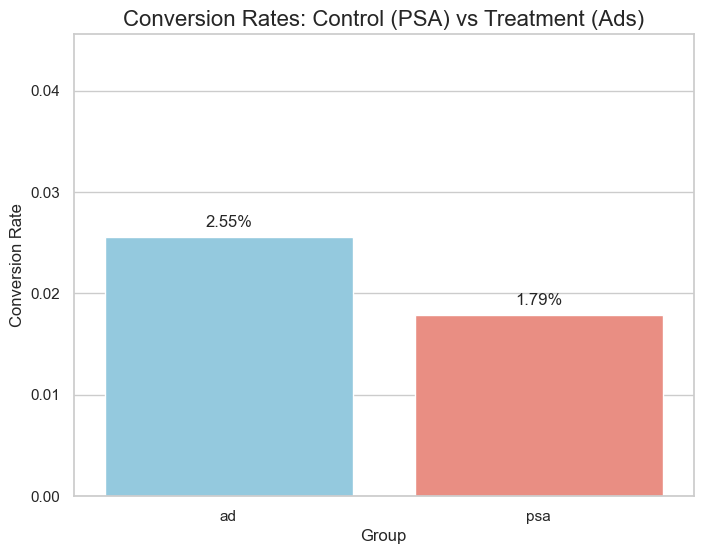

In [17]:
plt.figure(figsize=(8,6))

# Bar chart
sns.barplot(
    x='test group',
    y='conversion_rate',
    data=conversion_summary,
    palette=['skyblue','salmon']
)

# Annotate each bar with conversion rate %
for index, row in conversion_summary.iterrows():
    plt.text(index, row['conversion_rate'] + 0.001, f"{row['conversion_rate']*100:.2f}%", ha='center', fontsize=12)

plt.title("Conversion Rates: Control (PSA) vs Treatment (Ads)", fontsize=16)
plt.ylabel("Conversion Rate")
plt.xlabel("Group")
plt.ylim(0, conversion_summary['conversion_rate'].max() + 0.02)
plt.show()